# 06 · Evaluate — does the curriculum work?

Four systems on identical test sets:

| System | What it tells you |
|---|---|
| stock NLLB-600M into `kik_Latn` | what you get with no Ekegusii at all |
| **stage 1** | the model has learned Ekegusii — the baseline |
| **stage 2** | + PSA adaptation — the headline result |
| **mixed** | control — would one pass have done the same? |

**Three test sets**, each answering a different question:

| Test set | Question |
|---|---|
| `psa_ke_heldout` | **can it translate a real PSA?** ← the paper's headline |
| `bible` | did stage 2 forget the Ekegusii stage 1 taught it? |
| `lughayangu_contemporary` | does it handle everyday non-biblical language? |

**chrF2++ is the headline metric.** BLEU counts word n-grams, which is
structurally unfair to an agglutinative Bantu language where one word carries
what English spreads over five. Both are reported.

**Runtime** — 45–90 minutes for four systems.

In [32]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
sys.path.insert(0, str(pathlib.Path.cwd()))
import nb_common as C

C.set_seed()
C.use_house_style()
print(f"project root: {C.ROOT}")

project root: /home/jovyan/public-service-anouncement-MT


In [33]:
import json, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

try:
    import sacrebleu
except ImportError:
    raise SystemExit("pip install sacrebleu")

C.gpu_report()
C.require_files(C.DATA / "test.jsonl")
device = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if device == "cuda" else torch.float32
BATCH, BEAMS, MAX_LEN = 48, 4, 128

GPU 0: NVIDIA A100-SXM4-80GB
  total VRAM :   79.2 GB
  free  VRAM :   17.0 GB   <- size batches against THIS,
                                   the node is shared

torch 2.13.0+cu130  |  CUDA 13.0
  ok  test.jsonl                              1.4 MB


## 1. Test sets

In [34]:
rows = [json.loads(l) for l in open(C.DATA / "test.jsonl", encoding="utf-8")]
groups = defaultdict(list)
for r in rows:
    groups[(f"{r['src_lang']}->{r['tgt_lang']}", r["corpus"])].append(r)
for k, v in sorted(groups.items()):
    print(f"  {k[0]:<24} {k[1]:<26} {len(v):>6,}")

SYSTEMS = {"stage1": C.STAGE1_MODEL, "stage2": C.STAGE2_MODEL, "mixed": C.MIXED_MODEL}
SYSTEMS = {k: v for k, v in SYSTEMS.items() if v.exists()}
print("\nmodels found:", list(SYSTEMS) or "NONE - run train_stages.py")

  eng_Latn->guz_Latn       bible                       1,459
  eng_Latn->guz_Latn       lughayangu_contemporary       200
  eng_Latn->guz_Latn       psa_ke_heldout                570
  swh_Latn->guz_Latn       bible                       1,463
  swh_Latn->guz_Latn       psa_ke_heldout                371

models found: ['stage1', 'stage2', 'mixed']


## 2. Translation and scoring helpers

In [ ]:
@torch.no_grad()
def translate(model, tokenizer, texts, src_lang, tgt_lang, batch=BATCH, beams=BEAMS):
    eos, pad = tokenizer.eos_token_id, tokenizer.pad_token_id
    tgt_id = tokenizer.convert_tokens_to_ids(tgt_lang)
    out = []
    for i in range(0, len(texts), batch):
        chunk = texts[i:i + batch]
        enc = [[tokenizer.convert_tokens_to_ids(src_lang)] +
               tokenizer(t, add_special_tokens=False, truncation=True,
                         max_length=MAX_LEN - 2)["input_ids"] + [eos] for t in chunk]
        m = max(len(e) for e in enc)
        ids = torch.tensor([[pad] * (m - len(e)) + e for e in enc]).to(model.device)
        gen = model.generate(input_ids=ids, attention_mask=(ids != pad).long(),
                             forced_bos_token_id=tgt_id,
                             max_new_tokens=MAX_LEN, num_beams=beams)
        out += tokenizer.batch_decode(gen, skip_special_tokens=True)
    return out

def score(refs, hyps):
    return {"BLEU": sacrebleu.corpus_bleu(hyps, [refs]).score,
            "chrF2++": sacrebleu.CHRF(word_order=2).corpus_score(hyps, [refs]).score}

results, predictions = {}, {}

## 3. Stock NLLB as the floor

Ekegusii does not exist in the stock model, so the honest thing is to ask it for
the nearest language it does know — `kik_Latn`, Kikuyu. This is not a fair
comparison and should not be presented as one; it establishes what "no Ekegusii
support" looks like numerically.

In [36]:
base_tok = AutoTokenizer.from_pretrained(C.BASE_MODEL)
base = AutoModelForSeq2SeqLM.from_pretrained(C.BASE_MODEL, torch_dtype=DTYPE).to(device).eval()

for key, rows_ in sorted(groups.items()):
    src_lang, _ = key[0].split("->")
    hyps = translate(base, base_tok, [r["src"] for r in rows_], src_lang, C.GUZ_INIT_FROM)
    results[("stock", key)] = score([r["tgt"] for r in rows_], hyps)
    print(f"  stock  {key[0]:<22} {key[1]:<26} "
          f"chrF2++ {results[('stock', key)]['chrF2++']:5.2f}")

del base
torch.cuda.empty_cache() if device == "cuda" else None

Loading weights: 100%|██████████| 512/512 [00:00<00:00, 1192.13it/s]
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please 

  stock  eng_Latn->guz_Latn     bible                      chrF2++ 14.88


[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

  stock  eng_Latn->guz_Latn     lughayangu_contemporary    chrF2++ 11.41


[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

  stock  eng_Latn->guz_Latn     psa_ke_heldout             chrF2++ 14.56


[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

  stock  swh_Latn->guz_Latn     bible                      chrF2++ 14.65


[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

  stock  swh_Latn->guz_Latn     psa_ke_heldout             chrF2++ 14.13


## 4. The three fine-tuned systems

In [37]:
for name, path in SYSTEMS.items():
    tk = AutoTokenizer.from_pretrained(path)
    mdl = AutoModelForSeq2SeqLM.from_pretrained(path, torch_dtype=DTYPE).to(device).eval()
    print(f"\n--- {name} ---")
    for key, rows_ in sorted(groups.items()):
        src_lang, tgt_lang = key[0].split("->")
        hyps = translate(mdl, tk, [r["src"] for r in rows_], src_lang, tgt_lang)
        predictions[(name, key)] = hyps
        results[(name, key)] = score([r["tgt"] for r in rows_], hyps)
        print(f"  {key[0]:<22} {key[1]:<26} "
              f"BLEU {results[(name, key)]['BLEU']:5.2f}  "
              f"chrF2++ {results[(name, key)]['chrF2++']:5.2f}")
    del mdl
    torch.cuda.empty_cache() if device == "cuda" else None

Loading weights: 100%|██████████| 509/509 [00:00<00:00, 1391.06it/s]
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- stage1 ---


[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

  eng_Latn->guz_Latn     bible                      BLEU 19.75  chrF2++ 49.66


[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

...

  eng_Latn->guz_Latn     psa_ke_heldout             BLEU 12.33  chrF2++ 40.97


[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

  swh_Latn->guz_Latn     bible                      BLEU 19.97  chrF2++ 49.30


[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

  swh_Latn->guz_Latn     psa_ke_heldout             BLEU 10.66  chrF2++ 39.61


## 5. The comparison table

In [38]:
sysnames = ["stock"] + list(SYSTEMS)
table = []
for key in sorted(groups):
    row = {"direction": key[0].replace("_Latn", ""), "test set": key[1], "n": len(groups[key])}
    for s in sysnames:
        if (s, key) in results:
            row[f"{s} chrF"] = round(results[(s, key)]["chrF2++"], 2)
    table.append(row)
comparison = pd.DataFrame(table)
print(comparison.to_string(index=False))
comparison.to_csv(C.DATA / "evaluation_results.csv", index=False)

direction                test set    n  stock chrF  stage1 chrF  stage2 chrF  mixed chrF
 eng->guz                   bible 1459       14.88        49.66        48.95       49.81
 eng->guz lughayangu_contemporary  200       11.41        28.97        29.37       32.98
 eng->guz          psa_ke_heldout  570       14.56        23.96        34.93       40.97
 swh->guz                   bible 1463       14.65        49.11        48.80       49.30
 swh->guz          psa_ke_heldout  371       14.13        24.49        34.50       39.61


## 6. The two questions this notebook exists to answer

**Did stage 2 help on PSAs?** Compare stage 2 against stage 1 on
`psa_ke_heldout`. That difference is the value of the domain-adaptation phase.

**Did stage 2 forget?** Compare stage 2 against stage 1 on `bible`. A large drop
means the replay fraction is too low — raise `REPLAY_FRACTION` in notebook 02
and retrain stage 2.

**Was the curriculum worth it?** Compare stage 2 against `mixed`.

In [39]:
def get(sys_, corpus, direction="eng_Latn->guz_Latn"):
    k = (sys_, (direction, corpus))
    return results[k]["chrF2++"] if k in results else float("nan")

if "stage1" in SYSTEMS and "stage2" in SYSTEMS:
    psa_gain = get("stage2", "psa_ke_heldout") - get("stage1", "psa_ke_heldout")
    bible_drop = get("stage1", "bible") - get("stage2", "bible")
    print(f"PSA adaptation gain (stage2 - stage1 on real PSAs) : {psa_gain:+6.2f} chrF2++")
    print(f"Forgetting        (stage1 - stage2 on Bible)       : {bible_drop:+6.2f} chrF2++")
    if bible_drop > 3:
        print("\n  !! Stage 2 has forgotten a meaningful amount of general Ekegusii.")
        print("     Raise REPLAY_FRACTION in notebook 02 and retrain stage 2.")
    if "mixed" in SYSTEMS:
        curriculum = get("stage2", "psa_ke_heldout") - get("mixed", "psa_ke_heldout")
        print(f"\nCurriculum benefit (stage2 - mixed on real PSAs)   : {curriculum:+6.2f} chrF2++")
        print("  positive -> the two-stage ordering earned its place")
        print("  negative -> report the mixed model; the curriculum did not help")

PSA adaptation gain (stage2 - stage1 on real PSAs) : +10.97 chrF2++
Forgetting        (stage1 - stage2 on Bible)       :  +0.70 chrF2++

Curriculum benefit (stage2 - mixed on real PSAs)   :  -6.04 chrF2++
  positive -> the two-stage ordering earned its place
  negative -> report the mixed model; the curriculum did not help


## 7. Figure

saved figure -> /home/jovyan/public-service-anouncement-MT/artifacts/figures/06_system_comparison.png


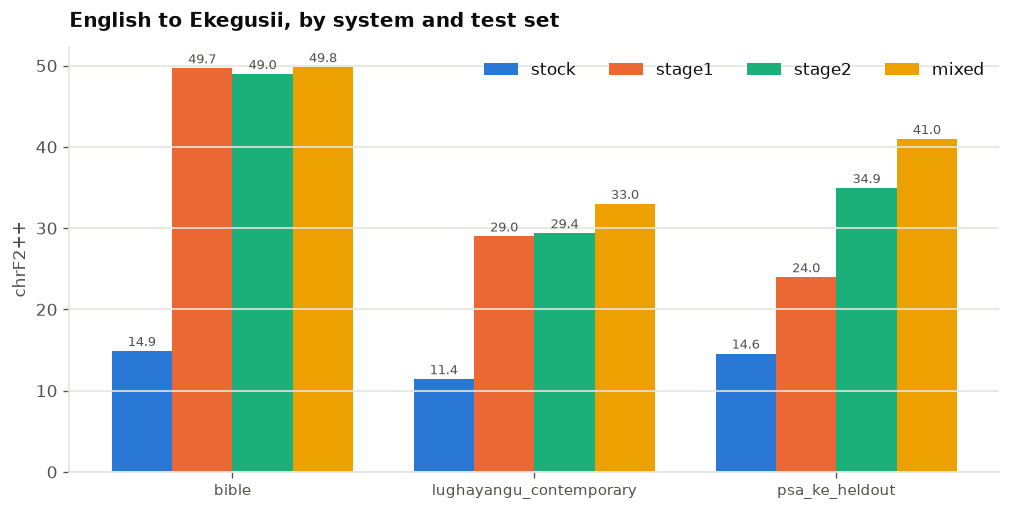

In [40]:
test_sets = sorted({k[1] for k in groups if k[0] == "eng_Latn->guz_Latn"})
x = np.arange(len(test_sets))
w = 0.8 / len(sysnames)

fig, ax = plt.subplots(figsize=(10, 4.6))
for i, s in enumerate(sysnames):
    vals = [get(s, ts) for ts in test_sets]
    pos = x + (i - (len(sysnames) - 1) / 2) * w
    ax.bar(pos, vals, w, label=s, color=C.PALETTE[i])
    for p, v in zip(pos, vals):
        if v == v:
            ax.annotate(f"{v:.1f}", (p, v), xytext=(0, 3), textcoords="offset points",
                        ha="center", fontsize=8, color=C.INK_MUTED)
ax.set_xticks(x); ax.set_xticklabels(test_sets, fontsize=9)
ax.set_ylabel("chrF2++"); ax.set_title("English to Ekegusii, by system and test set")
ax.legend(ncol=len(sysnames))
C.save_fig(fig, "06_system_comparison"); plt.show()

## 8. Per-domain breakdown on real PSAs — the paper's headline table

system: stage2

     domain   n  BLEU  chrF2++
Agriculture  51  7.88    35.05
  Education 173 11.06    38.21
 Governance  73  3.76    32.73
     Health 131  5.94    35.29
   Security 142  6.19    33.06
saved figure -> /home/jovyan/public-service-anouncement-MT/artifacts/figures/06_psa_by_domain.png


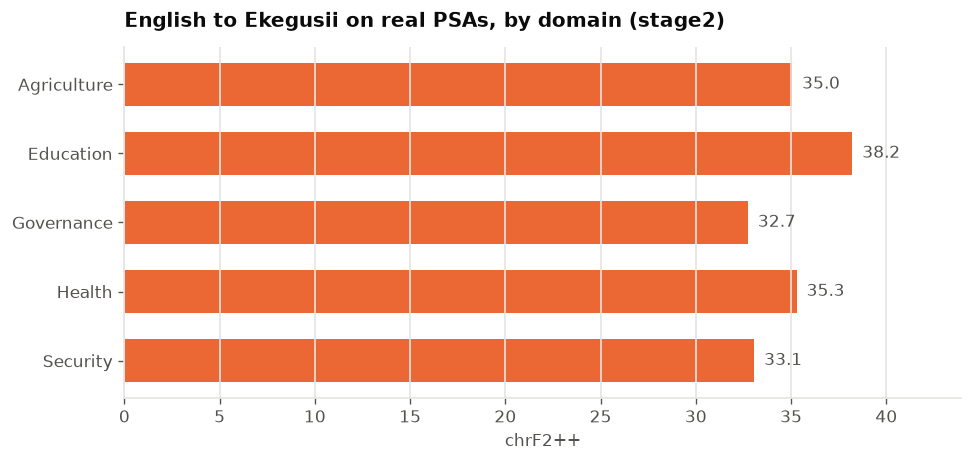

In [41]:
best = "stage2" if "stage2" in SYSTEMS else (list(SYSTEMS) or [None])[0]
key = ("eng_Latn->guz_Latn", "psa_ke_heldout")
if best and (best, key) in predictions:
    rows_, hyps = groups[key], predictions[(best, key)]
    per_domain = defaultdict(lambda: ([], []))
    for r, h in zip(rows_, hyps):
        per_domain[r.get("domain", "")][0].append(r["tgt"])
        per_domain[r.get("domain", "")][1].append(h)
    tbl = [{"domain": d, "n": len(refs), **{k: round(v, 2) for k, v in score(refs, hs).items()}}
           for d, (refs, hs) in sorted(per_domain.items()) if len(refs) >= 10]
    dom_df = pd.DataFrame(tbl)
    print(f"system: {best}\n")
    print(dom_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 3.8))
    bars = ax.barh(dom_df["domain"][::-1], dom_df["chrF2++"][::-1], color=C.PALETTE[1], height=0.62)
    for b, v in zip(bars, dom_df["chrF2++"][::-1]):
        ax.annotate(f"{v:.1f}", (v, b.get_y() + b.get_height()/2), xytext=(6, 0),
                    textcoords="offset points", va="center", color=C.INK_MUTED)
    ax.set_title(f"English to Ekegusii on real PSAs, by domain ({best})")
    ax.set_xlabel("chrF2++"); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    ax.set_xlim(0, max(dom_df["chrF2++"]) * 1.15)
    C.save_fig(fig, "06_psa_by_domain"); plt.show()

## 9. Bootstrap intervals, then read the actual output

A two-point chrF difference with no interval is not a result. And no metric will
tell you whether the Ekegusii *sounds like a public notice* rather than
scripture — for that you have to read it.

In [42]:
def bootstrap(refs, hyps, n=300, seed=C.SEED):
    """
    95% confidence interval for chrF2++ by resampling the test set.

    Written as an explicit loop: a walrus operator inside a comprehension's
    iterable expression is a SyntaxError, and - unhelpfully - ast.parse() does
    not catch it because the restriction is enforced when the symbol table is
    built, not when the source is parsed.
    """
    rng = np.random.default_rng(seed)
    metric = sacrebleu.CHRF(word_order=2)
    vals = []
    for _ in range(n):
        idx = rng.integers(0, len(refs), len(refs))
        vals.append(metric.corpus_score([hyps[i] for i in idx],
                                        [[refs[i] for i in idx]]).score)
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

for s in SYSTEMS:
    if (s, key) in predictions:
        lo, hi = bootstrap([r["tgt"] for r in groups[key]], predictions[(s, key)])
        print(f"  {s:<8} PSA chrF2++ {results[(s, key)]['chrF2++']:5.2f}  95% CI [{lo:.2f}, {hi:.2f}]")

  stage1   PSA chrF2++ 23.96  95% CI [23.12, 24.70]
  stage2   PSA chrF2++ 34.93  95% CI [34.17, 35.71]
  mixed    PSA chrF2++ 40.97  95% CI [39.94, 42.05]


In [43]:
if best and (best, key) in predictions:
    print(f"===== {best} on real PSAs =====")
    for r, h in list(zip(groups[key], predictions[(best, key)]))[:6]:
        print(f"\n  [{r.get('domain','')}]")
        print(f"  SRC : {r['src'][:96]}")
        print(f"  REF : {r['tgt'][:96]}")
        print(f"  HYP : {h[:96]}")

===== stage2 on real PSAs =====

  [Education]
  SRC : 100% transition policy: No child to repeat Class 8 from 2025.
  REF : Richiko riogotamboka gochia ayio emia ase emia: Mwana onde tari orairore ekerasi kia 8 korwa omw
  HYP : Omoroberio bwechisemi 100%: Abana tibakogenderera gosoa ekirasi kia 8 korwa omwaka 2025.

  [Education]
  SRC : 200 Stipendium Hungaricum scholarships open for Kenyan undergraduate students.
  REF : Omoroberio bweserikari kobwaterana neserikari ya Hungary (Hungaricum scholarships) oigoirwe ase 
  HYP : Chibesa 200 chiobobundi bwa'Hungaricum chiaigorwe ase abana besekenderi ba Kenya.

  [Education]
  SRC : Access education! Enroll pastoralist children in mobile schools.
  REF : Ekera chisemi! Rika abana babatugi ase omoroberio bwechisukuru chiokong,anyang,anya.
  HYP : Nyora chisemi! Somia abana baria bakorisia oborisia ase chisukuru chiesukuru.

  [Education]
  SRC : All Form 3 students must register as voters this week – no excuses!
  REF : abana besecondari 

In [44]:
C.save_json({f"{s}|{k[0]}|{k[1]}": v for (s, k), v in results.items()},
            C.DATA / "evaluation.json")
print("\nNext: 05_inference_and_export.ipynb")

wrote /home/jovyan/public-service-anouncement-MT/artifacts/data/evaluation.json

Next: 07_inference_and_export.ipynb
